# Group00 &middot; ds004504 &middot; Task 2b &mdash; Proposed GNN Model
**Track:** 1 &middot; GNN on table-style EEG data &middot; **Notebook:** `task2_proposed_model`

Builds a per-subject brain graph (nodes = 19 EEG channels, edges = functional connectivity) from the cached features and trains a Graph Convolutional Network, then compares its first result against the Task 2a baselines.



In [ ]:
from google.colab import drive
from pathlib import Path
import json

drive.mount('/content/drive')
SAVE_DIR = Path("/content/drive/MyDrive/EEG_Project_ds004504")

# Load saved baseline results
with open(SAVE_DIR / "baseline_results.json", "r") as f:
    baseline_summary = json.load(f)

print("Loaded baseline results!")
print("Best Model:", baseline_summary["best_model"])
print("Best Macro-F1:", baseline_summary["best_macro_f1"])

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded baseline results!
Best Model: SVM-RBF
Best Macro-F1: 0.595


In [ ]:
import torch

# Install PyTorch Geometric and required dependencies
!pip install -q torch-geometric torch-scatter torch-sparse -f https://data.pyg.org/whl/torch-{torch.__version__}.html

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 681.6/681.6 kB 13.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 51.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 36.9 MB/s eta 0:00:00


In [ ]:
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

torch.manual_seed(42); np.random.seed(42)
sns.set_theme(style="whitegrid")
GROUP_ORDER = ["A", "F", "C"]
GROUP_NAMES = {"A": "Alzheimer's (AD)", "F": "Frontotemporal Dementia (FTD)", "C": "Healthy Control (CN)"}
LABEL_MAP = {g: i for i, g in enumerate(GROUP_ORDER)}

FEATURE_CACHE, DEMO_CACHE = Path("features_cache.npz"), Path("demo_synthetic_features.npz")
if FEATURE_CACHE.exists():
    cache_path, MODE = FEATURE_CACHE, "REAL"
elif DEMO_CACHE.exists():
    cache_path, MODE = DEMO_CACHE, "DEMO"
else:
    raise FileNotFoundError("No feature cache found - run task2_baselines.ipynb first.")

cache = np.load(cache_path, allow_pickle=True)
node_feats, corr_adj, plv_adj = cache["node_feats"], cache["corr_adj"], cache["plv_adj"]
participant_id, group = cache["participant_id"], cache["group"]
y = np.array([LABEL_MAP[g] for g in group])
n_subj, n_ch, n_bands = node_feats.shape
print(f"[MODE={MODE}] Loaded {n_subj} subjects x {n_ch} channels x {n_bands} bands from {cache_path}")

with open("baseline_results.json") as f:
    baseline_summary = json.load(f)
train_idx = np.array(baseline_summary["split"]["train"])
val_idx = np.array(baseline_summary["split"]["val"])
test_idx = np.array(baseline_summary["split"]["test"])
best_baseline_name = baseline_summary["best_model"]
best_baseline_f1 = baseline_summary["best_macro_f1"]
print(f"Reusing task2a split -> train:{len(train_idx)} val:{len(val_idx)} test:{len(test_idx)}")
print(f"Baseline to beat: {best_baseline_name} (macro-F1={best_baseline_f1:.3f})")


[MODE=REAL] Loaded 88 subjects x 19 channels x 5 bands from features_cache.npz
Reusing task2a split -> train:59 val:11 test:18
Baseline to beat: SVM-RBF (macro-F1=0.595)


## Graph construction
**Nodes** = 19 EEG channels, **node features** = that channel's 5-band relative power. **Edges** = the subject's own functional-connectivity matrix (correlation by default here — Task 3 ablates PLV too), kept as a fully-connected weighted graph (|r| as edge weight, no self-loops); Task 3 also ablates sparsifying this to each node's top-k strongest connections. Building the graph **per-subject from only that subject's own recording** means graph construction cannot leak across the train/test split — each subject's edges never depend on any other subject.

In [ ]:
def build_edge_index_weight(adj, top_k=None):
    n = adj.shape[0]
    a = np.abs(adj.copy())
    np.fill_diagonal(a, 0)
    if top_k is not None:
        mask = np.zeros_like(a, dtype=bool)
        for i in range(n):
            mask[i, np.argsort(a[i])[-top_k:]] = True
        mask |= mask.T
        a = a * mask
    src, dst = np.nonzero(a)
    return (torch.tensor(np.stack([src, dst]), dtype=torch.long),
            torch.tensor(a[src, dst], dtype=torch.float))

def make_graph_dataset(node_feats, adj_stack, y, indices, feat_scaler=None, top_k=None):
    data_list = []
    for i in indices:
        x = node_feats[i]
        if feat_scaler is not None:
            x = feat_scaler.transform(x.reshape(1, -1)).reshape(x.shape)
        edge_index, edge_weight = build_edge_index_weight(adj_stack[i], top_k=top_k)
        data_list.append(Data(x=torch.tensor(x, dtype=torch.float), edge_index=edge_index,
                               edge_attr=edge_weight, y=torch.tensor([y[i]], dtype=torch.long)))
    return data_list

node_scaler = StandardScaler().fit(node_feats[train_idx].reshape(len(train_idx), -1))
train_ds = make_graph_dataset(node_feats, corr_adj, y, train_idx, node_scaler)
val_ds = make_graph_dataset(node_feats, corr_adj, y, val_idx, node_scaler)
test_ds = make_graph_dataset(node_feats, corr_adj, y, test_idx, node_scaler)
print("Example graph object:", train_ds[0])
print(f"-> 19 nodes x {n_bands} features, {train_ds[0].edge_index.shape[1]} directed edges "
      f"(fully-connected 19-node graph = 19x18 = {19*18})")


Example graph object: Data(x=[19, 5], edge_index=[2, 342], edge_attr=[342], y=[1])
-> 19 nodes x 5 features, 342 directed edges (fully-connected 19-node graph = 19x18 = 342)


## GNN architecture
A small 2-layer **GCN**: `GCNConv(5→32) → ReLU → Dropout → GCNConv(32→32) → ReLU → Dropout → global mean pool → Linear(32→3)`. Kept deliberately simple for a first result — Task 3 ablates depth, width, GAT/GraphSAGE variants, and the graph-construction choice.

In [ ]:
class EEG_GCN(nn.Module):
    def __init__(self, in_dim=5, hidden=32, n_layers=2, n_classes=3, dropout=0.3):
        super().__init__()
        dims = [in_dim] + [hidden] * n_layers
        self.convs = nn.ModuleList(GCNConv(a, b) for a, b in zip(dims[:-1], dims[1:]))
        self.dropout = dropout
        self.lin = nn.Linear(hidden, n_classes)

    def forward(self, x, edge_index, edge_weight, batch):
        for conv in self.convs:
            x = F.relu(conv(x, edge_index, edge_weight))
            x = F.dropout(x, p=self.dropout, training=self.training)
        x = global_mean_pool(x, batch)
        return self.lin(x)

@torch.no_grad()
def evaluate_gnn(model, dataset):
    model.eval()
    loader = DataLoader(dataset, batch_size=32, shuffle=False)
    all_pred, all_true = [], []
    for batch in loader:
        pred = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch).argmax(dim=1)
        all_pred.extend(pred.tolist()); all_true.extend(batch.y.tolist())
    return {"accuracy": accuracy_score(all_true, all_pred),
            "macro_f1": f1_score(all_true, all_pred, average="macro"),
            "y_true": all_true, "y_pred": all_pred}

def train_gnn(train_ds, val_ds, hidden=32, n_layers=2, epochs=80, lr=1e-3, class_weight=None):
    model = EEG_GCN(in_dim=n_bands, hidden=hidden, n_layers=n_layers)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    loader = DataLoader(train_ds, batch_size=16, shuffle=True)
    history = {"train_loss": [], "val_macro_f1": []}
    best_f1, best_state = -1, None
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        for batch in loader:
            opt.zero_grad()
            out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
            loss = F.cross_entropy(out, batch.y, weight=class_weight)
            loss.backward(); opt.step()
            epoch_loss += loss.item() * batch.num_graphs
        history["train_loss"].append(epoch_loss / len(train_ds))
        if val_ds:
            vf1 = evaluate_gnn(model, val_ds)["macro_f1"]
            history["val_macro_f1"].append(vf1)
            if vf1 > best_f1:
                best_f1, best_state = vf1, {k: v.clone() for k, v in model.state_dict().items()}
    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history

class_weights = torch.tensor([1.0 / (y[train_idx] == c).sum() for c in range(3)], dtype=torch.float)
class_weights = class_weights / class_weights.sum() * 3

gnn_model, history = train_gnn(train_ds, val_ds, class_weight=class_weights, epochs=80)
print("Training complete. Best val macro-F1:", round(max(history["val_macro_f1"]), 3))


Training complete. Best val macro-F1: 0.686


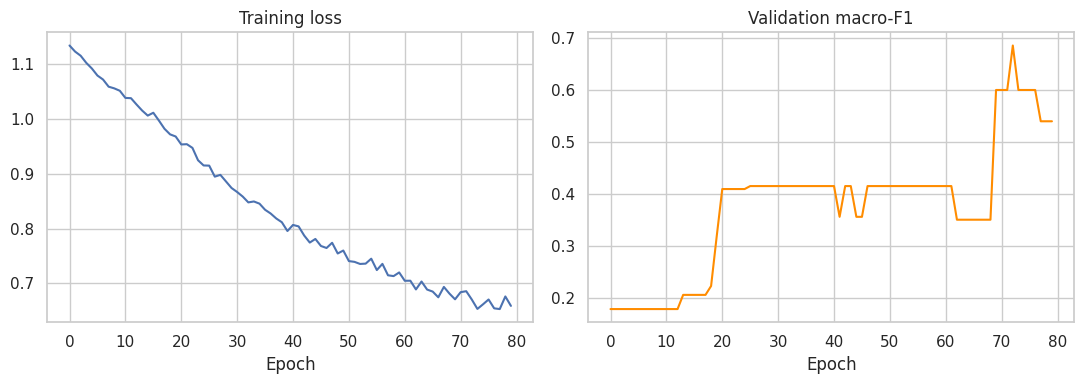

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history["train_loss"]); axes[0].set_title("Training loss"); axes[0].set_xlabel("Epoch")
axes[1].plot(history["val_macro_f1"], color="darkorange"); axes[1].set_title("Validation macro-F1"); axes[1].set_xlabel("Epoch")
plt.tight_layout(); plt.show()


## First GNN result vs. baselines

In [ ]:
gnn_test = evaluate_gnn(gnn_model, test_ds)
print(f"GNN (GCN, corr-graph) test -> accuracy={gnn_test['accuracy']:.3f}  macro-F1={gnn_test['macro_f1']:.3f}")
print(f"Best baseline ({best_baseline_name}) test macro-F1={best_baseline_f1:.3f}")
print()
print(classification_report(gnn_test["y_true"], gnn_test["y_pred"],
                             target_names=[GROUP_NAMES[g] for g in GROUP_ORDER]))


GNN (GCN, corr-graph) test -> accuracy=0.500  macro-F1=0.458
Best baseline (SVM-RBF) test macro-F1=0.595

                               precision    recall  f1-score   support

             Alzheimer's (AD)       0.60      0.43      0.50         7
Frontotemporal Dementia (FTD)       0.33      0.20      0.25         5
         Healthy Control (CN)       0.50      0.83      0.62         6

                     accuracy                           0.50        18
                    macro avg       0.48      0.49      0.46        18
                 weighted avg       0.49      0.50      0.47        18



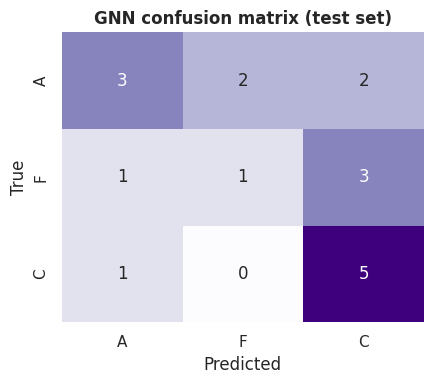

,Model,Macro-F1
0,SVM-RBF,0.595000
1,LogReg,0.464000
5,"GNN (GCN, first result)",0.458333
2,MLP,0.458000
3,XGBoost,0.383000
4,RandomForest,0.357000


In [ ]:
fig, ax = plt.subplots(figsize=(4.5, 4))
cm = confusion_matrix(gnn_test["y_true"], gnn_test["y_pred"])
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples", cbar=False, ax=ax,
            xticklabels=GROUP_ORDER, yticklabels=GROUP_ORDER)
ax.set_title("GNN confusion matrix (test set)", fontweight="bold")
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.tight_layout(); plt.show()

comparison = pd.DataFrame(baseline_summary["all_results"])[["Model", "Macro-F1"]]
comparison = pd.concat([comparison, pd.DataFrame([{"Model": "GNN (GCN, first result)",
                                                     "Macro-F1": gnn_test["macro_f1"]}])],
                        ignore_index=True).sort_values("Macro-F1", ascending=False)
comparison


In [ ]:
torch.save(gnn_model.state_dict(), "gnn_first_model.pt")
with open("gnn_first_result.json", "w") as f:
    json.dump({"mode": MODE, "test_accuracy": gnn_test["accuracy"], "test_macro_f1": gnn_test["macro_f1"]}, f, indent=2)
print("Saved gnn_first_model.pt and gnn_first_result.json for task3_improvement_ablation.ipynb")


Saved gnn_first_model.pt and gnn_first_result.json for task3_improvement_ablation.ipynb


## Summary
First GNN result on a fully-connected correlation-based brain graph, using the exact same train/val/test split and node-feature representation as the Task 2a baselines. `task3_improvement_ablation.ipynb` picks up from here to ablate graph type (correlation vs. PLV), architecture (GCN/GAT/GraphSAGE), depth/width, and run the 5-fold CV + significance test against the best baseline.

